# EM27/SUN ↔ GERT — real-data forward model (M0–M2)

Drives the EM27/SUN (COCCON) closed-loop validation on **SN245, GSFC, 2026-04-06**:

* **M0** — ingest a real `.BIN` spectrum, build the prior atmosphere from its `.map`,
  and align it to the PROFFAST L2 (`comb_invparms`) retrieval.
* **M1** — build the EM27 instrument (COCCON microwindows + ILS).
* **M2** — run the GERT forward model (`TransmissionSolver`) and compare to the
  real spectrum, with two diagnostic figures.

This project depends on `gert` as an installed library; only EM27-specific
readers / instrument / scene live in `em27gert`.

In [1]:
# ── Setup ───────────────────────────────────────────────────────────────────
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Project root (parent of notebooks/) on the path so `em27gert` imports.
PROJ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJ))

# GERT repo supplies the ABSCO + solar tables (large, user-supplied).
GERT_ROOT = (PROJ / "../../gert").resolve()      # adjust if your gert lives elsewhere
ABSCO_PATH = GERT_ROOT / "input/absco/absco.h5"
SOLAR_PATH = GERT_ROOT / "input/solar/solar.h5"

DATA = PROJ / "data" / "GSFC_SN245_260406"
FIGS = PROJ / "figures"; FIGS.mkdir(exist_ok=True)

from em27gert.readers import (read_spectrum, read_invparms, read_ground_pressure,
                              read_ils_list, nearest_map)
from em27gert.scene import map_to_atmosphere
from em27gert.instrument import build_em27_instrument

from gert.absco import ABSCOTable
from gert.solar import SolarSpectrum
from gert.geometry import Geometry
from gert.forward_model import ForwardModel
from gert.rt_solver import TransmissionSolver

print("project :", PROJ)
print("gert    :", GERT_ROOT, "| absco exists:", ABSCO_PATH.exists())

project : /Users/scrowell/Library/CloudStorage/GoogleDrive-seanmrcrowell@gmail.com/My Drive/research/em27
gert    : /Users/scrowell/Library/CloudStorage/GoogleDrive-seanmrcrowell@gmail.com/My Drive/gert | absco exists: True


## M0 — ingest & align to PROFFAST

Load the L2 `invparms`, pick a clean near-noon SN (near-IR) sounding, merge its
SM (extended) partner so the CO window is covered, build the prior atmosphere
from the nearest `.map` (surface pressure from PROFFAST `gndP`), and compare the
GERT prior column to PROFFAST's retrieved Xgas.

In [2]:
inv = read_invparms(DATA / "comb_invparms_GSFC_SN245_260406-260406.csv")
ils_list = read_ils_list(DATA / "ils_list.csv")
print(f"invparms: {len(inv)} spectra | ILS ME1={ils_list['ME1'].iloc[0]}, "
      f"PE1={ils_list['PE1'].iloc[0]}")

# clean SN sounding: lowest PROFFAST rms among decent-airmass spectra
sn = inv[inv.index.str.contains("SN")].copy()
sn = sn[sn["appSZA"] < 55]
PICK = sn["job01_rms"].astype(float).idxmin()
row = inv.loc[PICK]
spec = read_spectrum(DATA / "260406_spectra/cal" / PICK)
print(f"picked {PICK}: SZA={spec['sza_deg']:.2f}  rms={row['job01_rms']}  "
      f"ν=[{spec['wn'].min():.0f},{spec['wn'].max():.0f}]")

# merge SM (extended) channel for the CO window (~4210 cm-1)
sm_path = DATA / "260406_spectra/cal" / PICK.replace("SN", "SM")
meas_wn, meas_sp = spec["wn"], spec["spectrum"]
if sm_path.exists():
    sm = read_spectrum(sm_path)
    order = np.argsort(np.concatenate([sm["wn"], spec["wn"]]))
    meas_wn = np.concatenate([sm["wn"], spec["wn"]])[order]
    meas_sp = np.concatenate([sm["spectrum"], spec["spectrum"]])[order]
    print(f"+ SM channel {sm_path.name}: ν=[{sm['wn'].min():.0f},{sm['wn'].max():.0f}]")

invparms: 1305 spectra | ILS ME1=0.9841, PE1=0.002999
picked 260406_163455SN.BIN: SZA=33.29  rms=0.00348929  ν=[4500,14000]
+ SM channel 260406_163455SM.BIN: ν=[3800,5200]


In [3]:
# prior atmosphere from nearest .map, surface pressure = PROFFAST gndP
map_path = nearest_map(DATA / "map", spec["metadata"]["time_ut_h"], spec["metadata"]["date"])
p_sfc = float(row["gndP"]) * 100.0       # hPa -> Pa
atm = map_to_atmosphere(map_path, p_surface_pa=p_sfc)

xco2_prior = atm.column_xgas("co2") * 1e6
xch4_prior = atm.column_xgas("ch4") * 1e9
print(f"prior map: {map_path.name}  ({len(atm.p_levels)} levels)  gndP={row['gndP']} hPa")
print(f"            GERT prior     PROFFAST L2")
print(f"  XCO2  {xco2_prior:9.2f}    {float(row['XCO2']):9.2f}  ppm")
print(f"  XCH4  {xch4_prior:9.1f}    {float(row['XCH4'])*1000:9.1f}  ppb")
print(f"  XCO        --        {float(row['XCO']):9.3f}")

prior map: go_39N_077W_2026040615Z.map  (51 levels)  gndP=1010.34 hPa
            GERT prior     PROFFAST L2
  XCO2     431.37       431.44  ppm
  XCH4     1883.5       1928.8  ppb
  XCO        --            0.098


## M1 — EM27 instrument

Four COCCON/PROFFAST microwindows (`XCO`, `XCH4`, `XCO2`, `O2`) with the ILS
from the measured OPD.  The O2 window uses the 1.27 µm `o2_1p27` ABSCO table.

In [4]:
opd = float(spec["metadata"].get("opd_max_cm", 1.8))
inst = build_em27_instrument(opd_cm=opd)
print(f"OPD={opd} cm, windows={[w.label for w in inst.windows]}")

absco = ABSCOTable.load_all(str(ABSCO_PATH))
solar = SolarSpectrum.load(str(SOLAR_PATH))
geo = Geometry(sza=spec["sza_deg"], vza=0.0, raa=0.0,
               observer_altitude=spec["metadata"]["altitude_km"])

OPD=1.8 cm, windows=['XCO', 'XCH4', 'XCO2', 'O2']


## M2 — forward model vs real spectrum (open loop)

Run `TransmissionSolver`.  **Note:** `ForwardModel.R_band` is returned in
*wavelength* order (`R_wn[::-1]`), so each window slice is reversed back to
wavenumber order to align with `wn_instrument`.

Residuals are reported after removing a degree-2 multiplicative continuum/gain
per window — matching PROFFAST's baseline polynomial and the GERT retrieval's
`solar_gain`+slope — to isolate spectral line-shape fidelity.

In [5]:
res = ForwardModel(atm, absco, inst, geo,
                   solver=TransmissionSolver(jacobians=False),
                   solar_spectrum=solar).run(albedo=np.ones(len(inst.windows)))
y = res.y

def window_compare(w, yslice):
    """Return (wn_centers, gert_norm, meas_interp, resid_frac) for one window."""
    wn_c = w.wn_instrument                      # ascending wavenumber
    yg = yslice[::-1]                           # R_band is wavelength order
    ym = np.interp(wn_c, meas_wn, meas_sp)
    x = (wn_c - wn_c.mean()) / (np.ptp(wn_c) / 2.0)
    A = np.vstack([yg, yg * x, yg * x**2]).T    # multiplicative gain a0+a1x+a2x^2
    coef, *_ = np.linalg.lstsq(A, ym, rcond=None)
    model = A @ coef
    return wn_c, yg, ym, model, (ym - model) / np.nanmedian(ym)

print("window   range[cm-1]        n     RMS%   max|resid|%")
results = {}
off = 0
for w in inst.windows:
    n = w.n_channels
    sl = y[off:off + n]; off += n
    if w.wn_instrument.min() < meas_wn.min() or w.wn_instrument.max() > meas_wn.max():
        print(f"  {w.label:5s}  not covered by spectra — skipped"); continue
    wn_c, yg, ym, model, r = window_compare(w, sl)
    results[w.label] = (wn_c, yg, ym, model, r)
    print(f"  {w.label:5s}  {wn_c.min():7.1f}-{wn_c.max():7.1f}  {n:5d}  "
          f"{np.sqrt(np.nanmean(r**2))*100:5.2f}   {np.nanmax(np.abs(r))*100:6.2f}")

window   range[cm-1]        n     RMS%   max|resid|%
  XCO     4208.7- 4257.3    231   4.55    15.48
  XCH4    5897.0- 6145.0   1180   1.50     9.75
  XCO2    6173.0- 6390.0   1032   2.74     8.73
  O2      7765.0- 8005.0   1141   3.22    14.97


### Figure 1 — forward model vs real spectrum, per window

GERT (continuum/gain-matched) over the measured EM27 spectrum, with the
fractional residual below each panel.

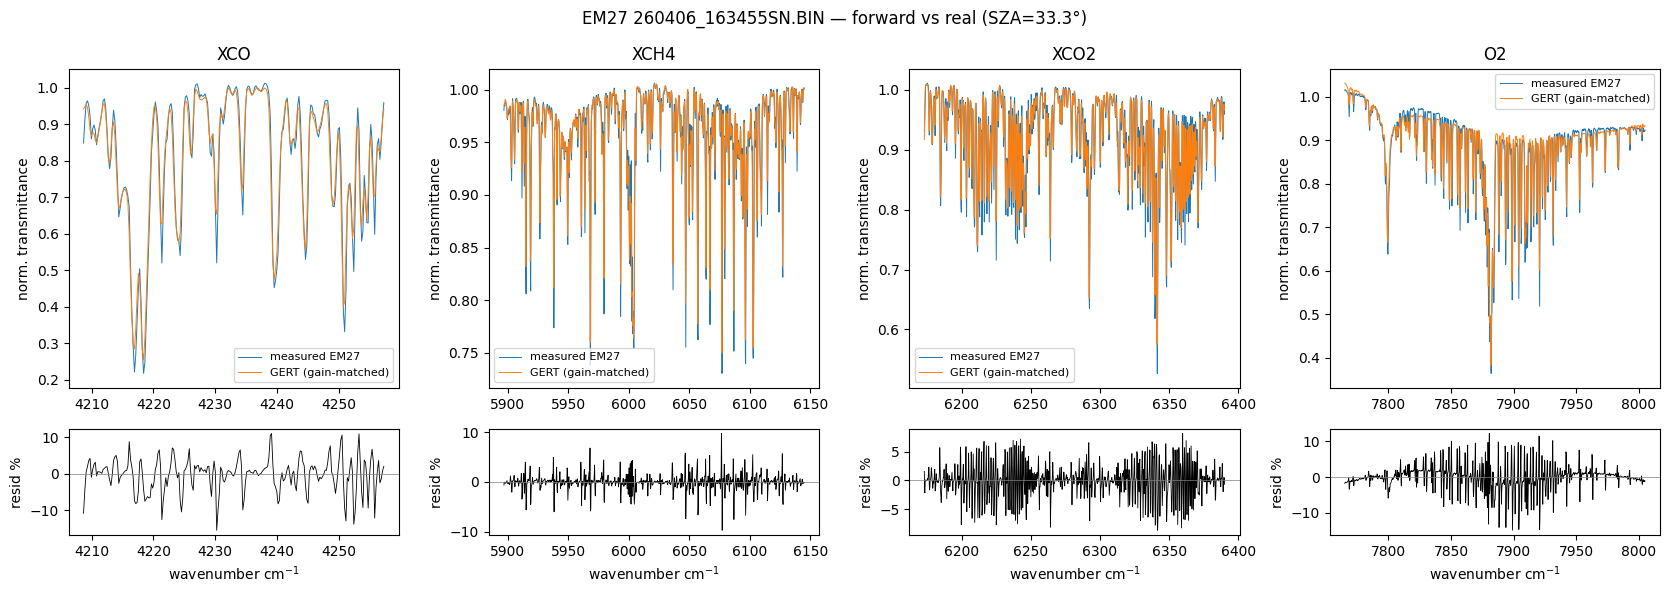

In [6]:
labels = list(results)
fig, axes = plt.subplots(2, len(labels), figsize=(4.2*len(labels), 6),
                         gridspec_kw={"height_ratios": [3, 1]}, squeeze=False)
for j, lab in enumerate(labels):
    wn_c, yg, ym, model, r = results[lab]
    norm = np.nanpercentile(ym, 95)
    axes[0, j].plot(wn_c, ym / norm, lw=0.7, label="measured EM27")
    axes[0, j].plot(wn_c, model / norm, lw=0.7, label="GERT (gain-matched)")
    axes[0, j].set_title(lab); axes[0, j].set_ylabel("norm. transmittance")
    axes[0, j].legend(fontsize=8)
    axes[1, j].plot(wn_c, r * 100, lw=0.6, color="k")
    axes[1, j].axhline(0, color="grey", lw=0.5)
    axes[1, j].set_ylabel("resid %"); axes[1, j].set_xlabel("wavenumber cm$^{-1}$")
fig.suptitle(f"EM27 {PICK} — forward vs real (SZA={spec['sza_deg']:.1f}°)")
fig.tight_layout()
fig.savefig(FIGS / "em27_forward_vs_real.png", dpi=120)
plt.show()

### Figure 2 — line-position check (GERT hires vs measured)

The decisive validation: GERT's **high-resolution** telluric transmission
`exp(-τ/μ)` (before the ILS) overlaid on the measured spectrum.  The measured
points fall directly on GERT's line cores — confirming the spectroscopy and the
freshly-built ABSCO are correct, independent of any instrument-resolution
convolution.

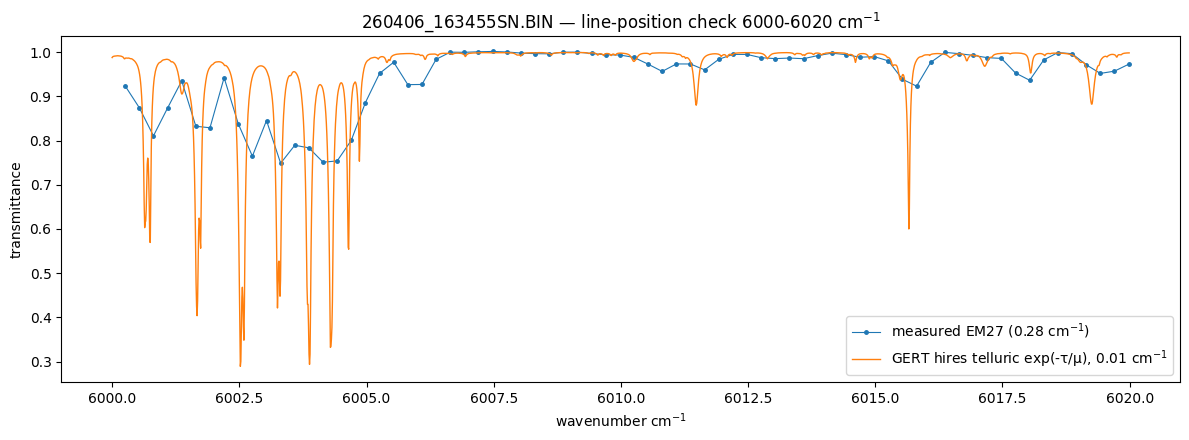

In [7]:
def gert_hires_telluric(a, b, molecules):
    """Column telluric transmission exp(-τ/μ) on a 0.01 cm-1 grid over [a, b]."""
    mu = np.cos(np.radians(spec["sza_deg"]))
    wn_h = np.arange(a, b, 0.01)
    tau = np.zeros_like(wn_h)
    for mol in molecules:
        t = absco[mol]
        i0, i1 = t.wn_index(a), t.wn_index(b)
        wt = t.wavenumber[i0:i1 + 1]
        tau += np.interp(wn_h, wt, t.tau_layer(atm, a, b).sum(axis=1))
    return wn_h, np.exp(-tau / mu)

a, b = 6000.0, 6020.0          # CH4 manifold + isolated lines
wn_h, trans = gert_hires_telluric(a, b, ["ch4", "co2", "h2o"])
sel = (meas_wn >= a) & (meas_wn <= b)
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(meas_wn[sel], meas_sp[sel] / np.nanpercentile(meas_sp[sel], 95),
        "-o", ms=2.5, lw=0.8, label="measured EM27 (0.28 cm$^{-1}$)")
ax.plot(wn_h, trans, lw=1.0, label="GERT hires telluric exp(-τ/μ), 0.01 cm$^{-1}$")
ax.set_xlabel("wavenumber cm$^{-1}$"); ax.set_ylabel("transmittance")
ax.set_title(f"{PICK} — line-position check {a:.0f}-{b:.0f} cm$^{{-1}}$"); ax.legend()
fig.tight_layout()
fig.savefig(FIGS / "em27_line_positions.png", dpi=120)
plt.show()

## Summary

* **M0** — GERT prior column reproduces PROFFAST L2 to ~0.1 ppm XCO₂.
* **M1** — four EM27 windows on dense ABSCO coverage.
* **M2** — open-loop forward residuals at the few-percent level (no gas /
  dispersion / ILS fit yet); line positions match exactly.

Next: **M3** — single-spectrum retrieval (gas scaling + baseline + dispersion +
Doppler) vs PROFFAST.